In [ ]:
%pip install matplotlib

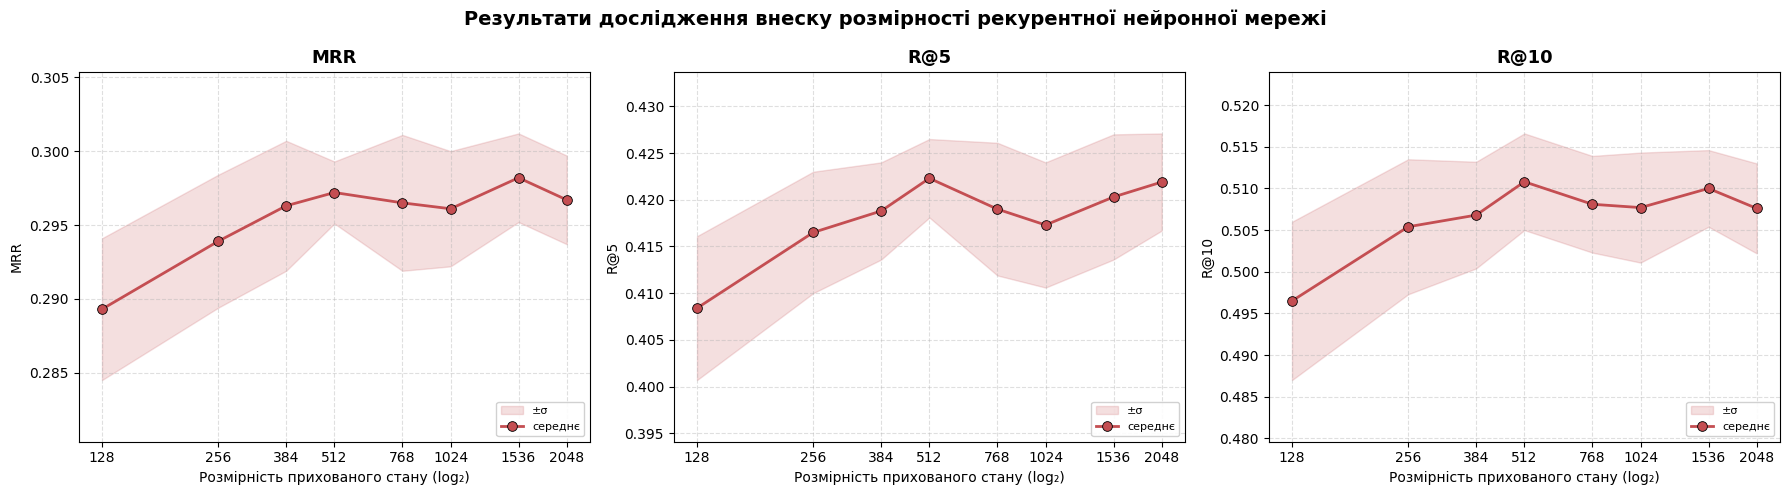

In [13]:
import matplotlib.pyplot as plt
import numpy as np

hidden_dims = np.array([128, 256, 384, 512, 768, 1024, 1536, 2048])

mrr      = np.array([0.2893, 0.2939, 0.2963, 0.2972, 0.2965, 0.2961, 0.2982, 0.2967])
mrr_std  = np.array([0.0048, 0.0045, 0.0044, 0.0021, 0.0046, 0.0039, 0.0030, 0.0030])

r5       = np.array([0.4084, 0.4165, 0.4188, 0.4223, 0.4190, 0.4173, 0.4203, 0.4219])
r5_std   = np.array([0.0077, 0.0065, 0.0052, 0.0042, 0.0071, 0.0067, 0.0067, 0.0052])

r10      = np.array([0.4965, 0.5054, 0.5068, 0.5108, 0.5081, 0.5077, 0.5100, 0.5076])
r10_std  = np.array([0.0095, 0.0081, 0.0064, 0.0058, 0.0058, 0.0066, 0.0046, 0.0054])

metrics = [
    ('MRR',    mrr, mrr_std),
    ('R@5',  r5,  r5_std),
    ('R@10', r10, r10_std),
]

chosen_dim = 512
line_color = '#C44E52'
band_color = '#C44E52'
ref_color  = '#4C72B0'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for ax, (name, vals, errs) in zip(axes, metrics):
    ax.fill_between(hidden_dims, vals - errs, vals + errs,
                    color=band_color, alpha=0.18, label='±σ')
    ax.plot(hidden_dims, vals, marker='o', color=line_color,
            linewidth=2, markersize=7, markeredgecolor='black',
            markeredgewidth=0.6, label='середнє')

    idx_full = int(np.where(hidden_dims == chosen_dim)[0][0])
    full_val = vals[idx_full]

    ax.set_xscale('log', base=2)
    ax.set_xticks(hidden_dims)
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v)}'))
    ax.minorticks_off()

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Розмірність прихованого стану (log₂)')
    ax.set_ylabel(name)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

    lo = float((vals - errs).min())
    hi = float((vals + errs).max())
    pad = (hi - lo) * 0.25
    ax.set_ylim(lo - pad, hi + pad)

    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)

fig.suptitle('Результати дослідження внеску розмірності рекурентної нейронної мережі',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()